In [1]:
EXPERIMENT = "ChemHomeo"

SAVE_FIGURES = False

# Imports

In [2]:
import jax
import jax.numpy as np
import equinox as eqx

jax.config.update("jax_enable_x64", True)

import jax_morph as jxm  # type: ignore

key = jax.random.PRNGKey(0)

import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 22})

from tqdm import tqdm

In [3]:
import os

if SAVE_FIGURES:
    # create the figures subdirectory if it doesn't exist
    os.makedirs("figures", exist_ok=True)

## Load Results Fn

In [6]:
def load_run_data_fig3(run_id):
    """Load training log, initial state, and trained model for a given run.

    Args:
        run_id: String identifier for the training run

    Returns:
        opt_hyper: Training hyperparams
        training_log: ReinforceTrainingLog object
        istate: Initial CellState
        initial_model: Initial model
        trained_model: Trained model
    """

    # key is not actually used in the code, but is required by the function signature
    # (we load weights from the savedmodels)
    key = jax.random.PRNGKey(0)

    # Load training hyperparams
    import json

    # load json
    with open(f"trained_models/train-{EXPERIMENT}-opt-hyperparams.json", "r") as f:
        opt_hyper = json.load(f)

    N_EPOCHS = opt_hyper["EPOCHS"]

    root_dir = f"trained_models/train-{EXPERIMENT}-{run_id}"

    # Load training metrics log
    from collections import namedtuple

    OptLog = namedtuple("OptimizationLog", ["loss", "val_loss"])
    training_log = OptLog([0.0] * (N_EPOCHS + 1), [0.0] * (N_EPOCHS + 1))

    with open(f"{root_dir}/results-{EXPERIMENT}-{run_id}.eqx", "rb") as fh:
        training_log = eqx.tree_deserialise_leaves(fh, like=training_log)

    # Load initial state and model builder functions
    from fig3_istate_and_model import build_istate, build_model

    # Load initial state
    istate = build_istate(key)

    # Load model
    model = build_model(key, istate)

    # Load initial model
    with open(f"{root_dir}/init-{EXPERIMENT}-{run_id}.eqx", "rb") as fh:
        initial_model = eqx.tree_deserialise_leaves(fh, like=model)

    # Load trained model
    with open(f"{root_dir}/trained-{EXPERIMENT}-{run_id}.eqx", "rb") as fh:
        trained_model = eqx.tree_deserialise_leaves(fh, like=model)

    return opt_hyper, training_log, istate, initial_model, trained_model

# Single Optimization Run 

In [7]:
RUN_ID = 0

In [8]:
opt_hyper, training_log, istate, initial_model, trained_model = load_run_data_fig3(
    RUN_ID
)

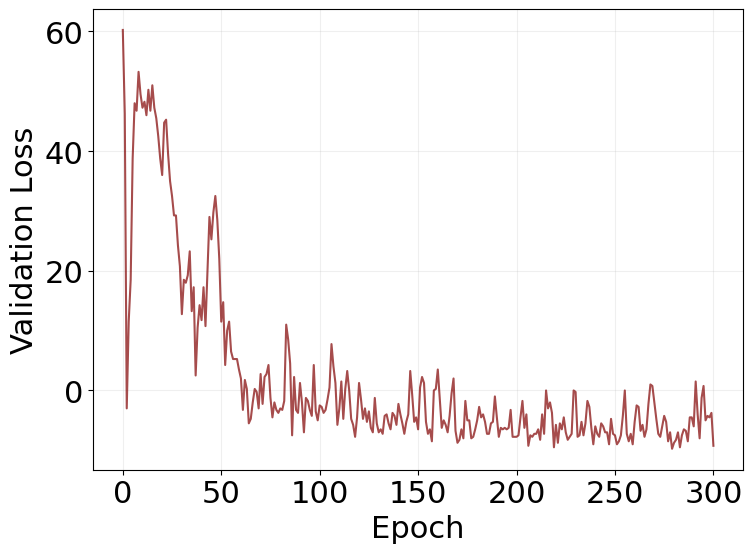

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(training_log.val_loss, color="maroon", alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(alpha=0.2)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f"figures/loss_curve_{EXPERIMENT}-{RUN_ID}.svg", dpi=300)

## Loss Distributions

In [10]:
def _final_cost_distribution(model, istate, subkeys, n_sim_steps):
    vsim = jax.vmap(jxm.simulate, (None, None, 0, None))

    fstate, _ = vsim(model, istate, subkeys, n_sim_steps)

    N = fstate.celltype.sum(-1).sum(-1)
    cost = fstate.celltype.sum(-2) @ np.asarray([1.0, 0.0]) / N

    return cost.flatten()

In [11]:
N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))
subkeys = jax.random.split(key, 300)

icosts = _final_cost_distribution(initial_model, istate, subkeys, n_sim_steps=N_ADD)
ocosts = _final_cost_distribution(trained_model, istate, subkeys, n_sim_steps=N_ADD)

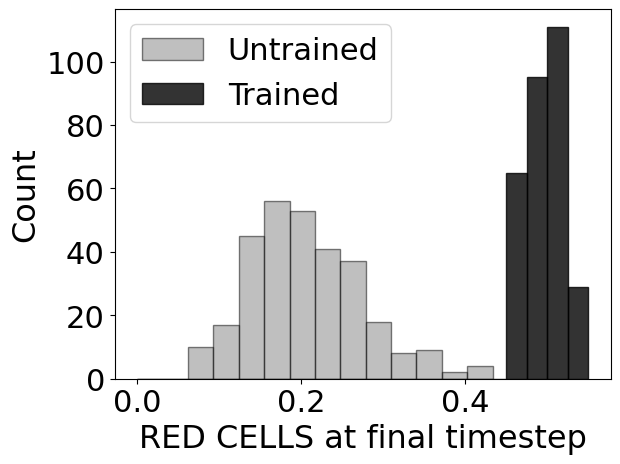

In [12]:
plt.hist(
    icosts,
    color="gray",
    edgecolor="black",
    alpha=0.5,
    label="Untrained",
    bins=np.linspace(0, icosts.max(), 15),
)
plt.hist(
    ocosts,
    color="black",
    edgecolor="black",
    alpha=0.8,
    label="Trained",
    bins=np.linspace(0, ocosts.max(), 23),
)

plt.xlabel("RED CELLS at final timestep", fontsize=23)
plt.ylabel("Count", fontsize=23)

plt.legend()

if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-finalcosts-dist.svg", bbox_inches="tight"
    )

## Initial State

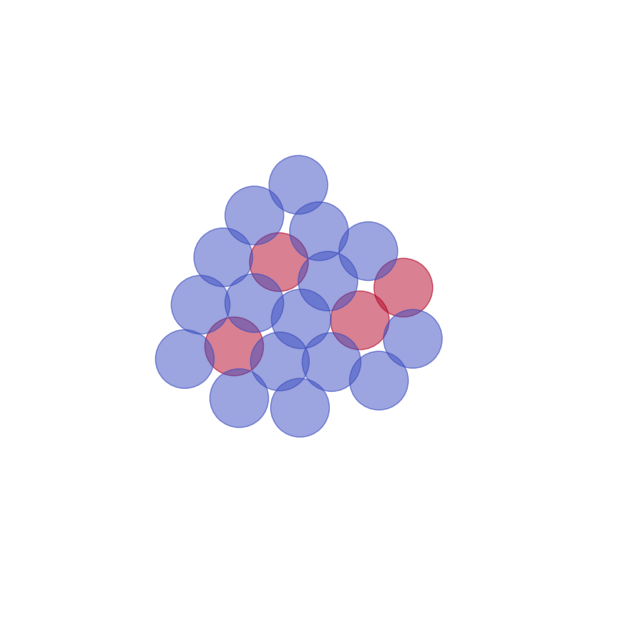

In [13]:
fig, ax = jxm.visualization.draw_circles_ctype(istate, cm=plt.cm.coolwarm_r)

if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-initial_istate.svg", bbox_inches="tight"
    )

## Initialized model

In [14]:
# RUN SIMULATION

N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))

key, subkey = jax.random.split(key)
fstate_i, _ = jxm.simulate(initial_model, istate, subkey, N_ADD)

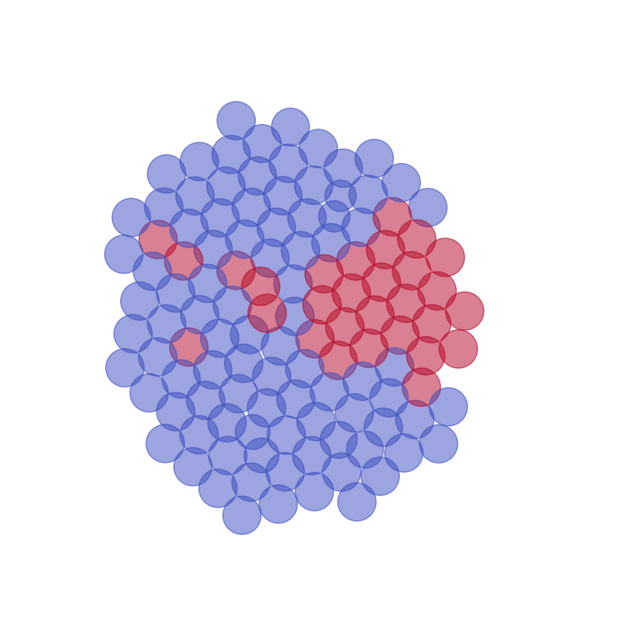

In [15]:
fig, ax = jxm.visualization.draw_circles_ctype(fstate_i, cm=plt.cm.coolwarm_r)

if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-untrained-fstate.svg", bbox_inches="tight"
    )

## Trained model

In [16]:
# RUN SIMULATION
N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))

key, subkey = jax.random.split(key)
fstate_opt, _ = jxm.simulate(trained_model, istate, subkey, N_ADD)

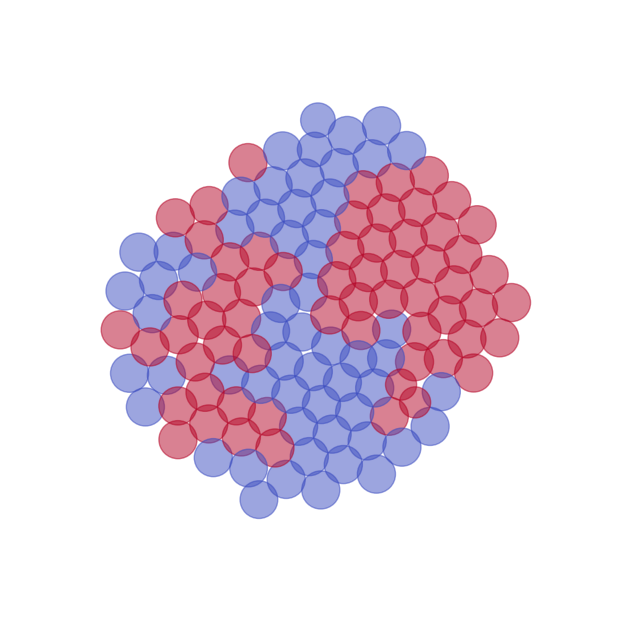

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax = jxm.visualization.draw_circles_ctype(fstate_opt, ax=ax, cm=plt.cm.coolwarm_r)

if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-trained-fstate.svg", bbox_inches="tight"
    )

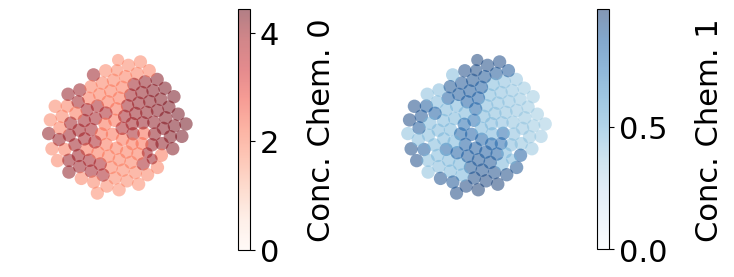

In [18]:
fig, axs = plt.subplots(1, 2)

cmaps = [plt.cm.Reds, plt.cm.Blues]

for i in range(2):
    jxm.visualization.draw_circles_chem(
        fstate_opt, chem=i, ax=axs[i], colorbar=True, cm=cmaps[i]
    )

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-trained-fstate-allchem.svg", bbox_inches="tight"
    )

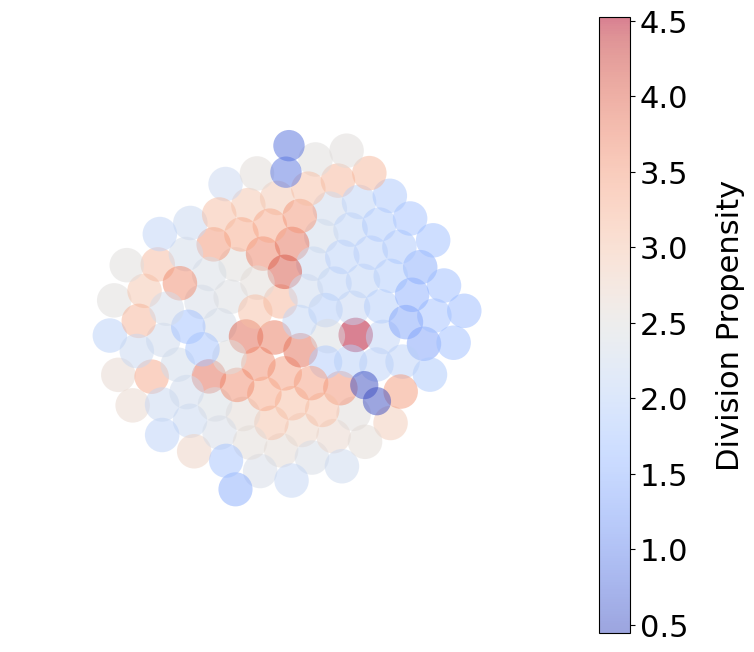

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax = jxm.visualization.draw_circles_division(fstate_opt, ax=ax)

if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-trained-division.svg", bbox_inches="tight"
    )

### Division Propensity Dynamics

In [20]:
# RUN SIMULATION
N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))

key, subkey = jax.random.split(key)
fstate_opt_history, _ = jxm.simulate(trained_model, istate, subkey, N_ADD, history=True)

# N_EXTRA = 200
# fstate_opt_history, _ = jxm.simulate(
#     trained_model,
#     istate.elongate(N_EXTRA),
#     subkey,
#     N_ADD + N_EXTRA,
#     history=True,
# )

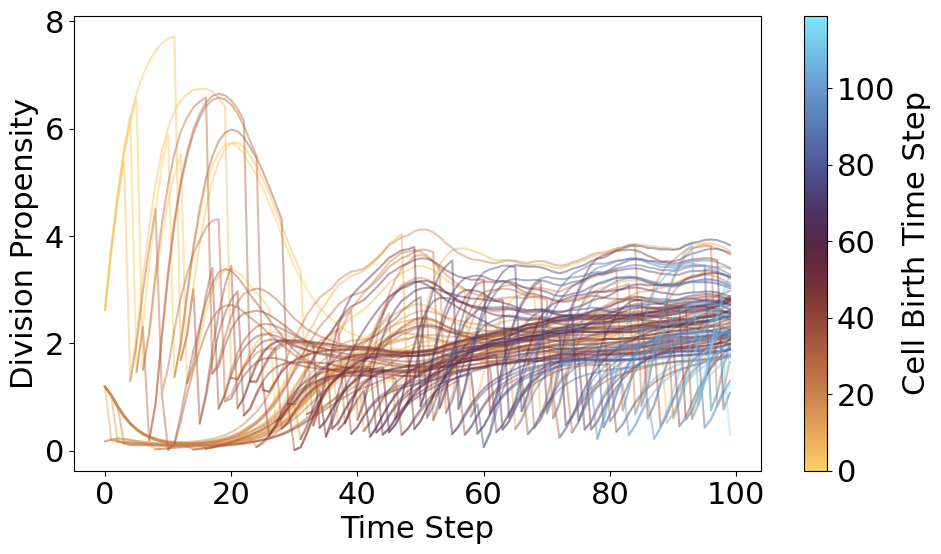

In [21]:
# Use managua colormap for sequential coloring
colors = plt.cm.managua(
    np.linspace(0, 1, fstate_opt_history.division.squeeze().T.shape[0])
)
alphas = np.linspace(
    0.5, 0.4, fstate_opt_history.division.squeeze().T.shape[0]
).tolist()

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(fstate_opt_history.division.squeeze().T.shape[0]):
    # Get trajectory and find first non-zero value
    traj = fstate_opt_history.division.squeeze().T[i]
    traj = np.array(traj)  # Convert from JAX array to numpy array
    first_nonzero = int(np.where(traj != 0)[0][0]) if np.any(traj != 0) else len(traj)

    # Create array with None values for initial zeros
    plot_traj = [None] * first_nonzero + traj[first_nonzero:].tolist()

    ax.plot(plot_traj, color=colors[i], alpha=alphas[i])

ax.set_ylabel("Division Propensity")
ax.set_xlabel("Time Step")

# Add colorbar
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.managua,
    norm=plt.Normalize(
        vmin=0, vmax=fstate_opt_history.division.squeeze().T.shape[0] - 1
    ),
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Cell Birth Time Step", rotation=90, labelpad=5)

plt.tight_layout()
plt.show()

### Over-simulation

In [22]:
N_EXTRA = 150

key, subkey = jax.random.split(key)
fstate_opt_long, _ = jxm.simulate(
    trained_model, istate.elongate(N_EXTRA), subkey, N_ADD + N_EXTRA
)

print(fstate_opt_long.celltype.sum(-2)[0] / fstate_opt_long.celltype.sum(-2).sum())

0.4962962962962963


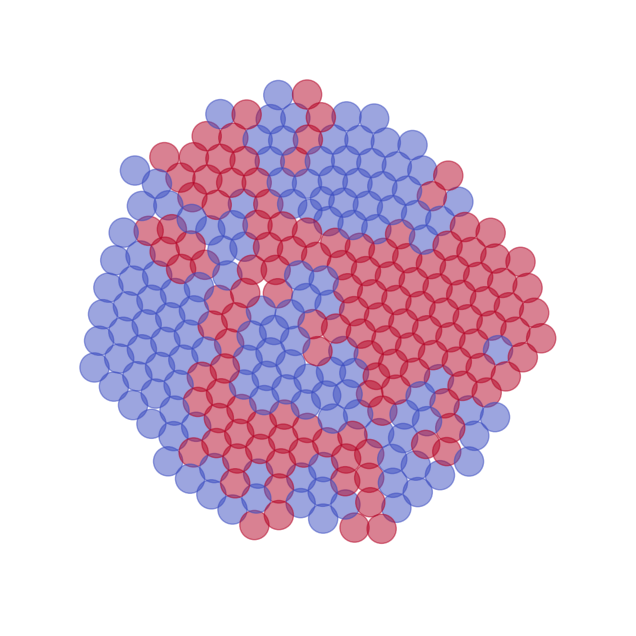

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ax = jxm.visualization.draw_circles_ctype(fstate_opt_long, ax=ax, cm=plt.cm.coolwarm_r)


if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-trained-extra{N_EXTRA}.svg", bbox_inches="tight"
    )

# Generalization

## Simulation Length

In [24]:
from fig3_istate_and_model import build_istate

In [25]:
oversim_costs_trained = []

N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))
n_steps = np.arange(N_ADD - 40, N_ADD + 200, 15)
key, *loop_subkeys = jax.random.split(key, len(n_steps) + 1)


vsim = jax.vmap(jxm.simulate, (None, None, 0, None))

N_REPS = 100

for n_step, sk in tqdm(zip(n_steps, loop_subkeys), total=len(n_steps)):

    subkeys = jax.random.split(sk, 1 + N_REPS)

    istate_tmp = build_istate(subkeys[0])

    if n_step > N_ADD:
        istate_tmp = istate_tmp.elongate(n_step - N_ADD)

    fstate, _ = vsim(trained_model, istate_tmp, subkeys[1:], int(n_step))

    N = fstate.celltype.sum(-1).sum(-1)
    cost = fstate.celltype.sum(-2)[:, 0] / N

    oversim_costs_trained += [cost.flatten()]

100%|███████████████████████████████████████████| 16/16 [02:23<00:00,  8.95s/it]


In [26]:
oversim_costs_untrained = []

N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))
n_steps = np.arange(N_ADD - 40, N_ADD + 200, 15)
key, *loop_subkeys = jax.random.split(key, len(n_steps) + 1)


vsim = jax.vmap(jxm.simulate, (None, None, 0, None))

N_REPS = 100

for n_step, sk in tqdm(zip(n_steps, loop_subkeys), total=len(n_steps)):

    subkeys = jax.random.split(sk, 1 + N_REPS)

    istate_tmp = build_istate(subkeys[0])

    if n_step > N_ADD:
        istate_tmp = istate_tmp.elongate(n_step - N_ADD)

    fstate, _ = vsim(initial_model, istate_tmp, subkeys[1:], int(n_step))

    N = fstate.celltype.sum(-1).sum(-1)
    cost = fstate.celltype.sum(-2)[:, 0] / N

    oversim_costs_untrained += [cost.flatten()]

  0%|                                                    | 0/16 [00:00<?, ?it/s]

100%|███████████████████████████████████████████| 16/16 [02:11<00:00,  8.20s/it]


In [27]:
# AVG AND STD FOR TRAINED AND UNTRAINED

oversim_avgs_o = np.mean(np.array(oversim_costs_trained), axis=1)
oversim_stds_o = np.std(np.array(oversim_costs_trained), axis=1)

oversim_avgs_i = np.mean(np.array(oversim_costs_untrained), axis=1)
oversim_stds_i = np.std(np.array(oversim_costs_untrained), axis=1)

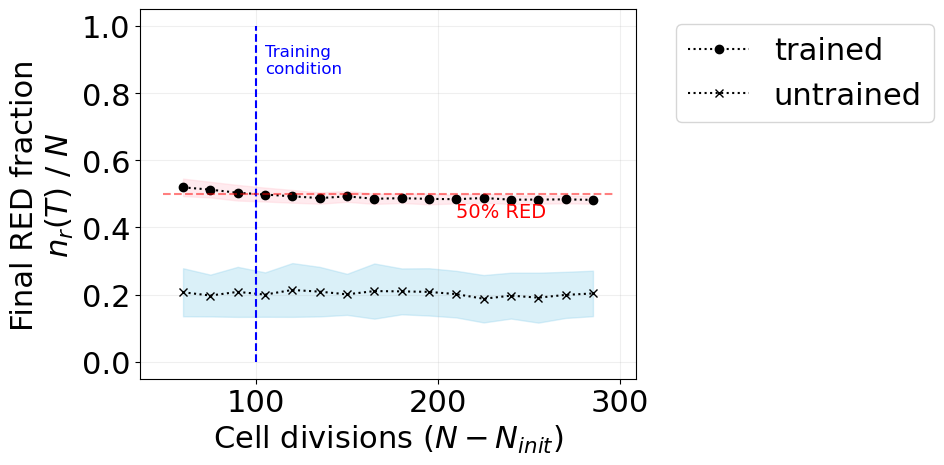

In [28]:
n_init = istate.celltype.sum(-1).sum(-1)

plt.plot(n_steps, oversim_avgs_o, "ko:", label="trained")
plt.fill_between(
    n_steps,
    oversim_avgs_o - oversim_stds_o,
    oversim_avgs_o + oversim_stds_o,
    alpha=0.3,
    color="pink",
)

plt.plot(n_steps, oversim_avgs_i, "kx:", label="untrained")
plt.fill_between(
    n_steps,
    oversim_avgs_i - oversim_stds_i,
    oversim_avgs_i + oversim_stds_i,
    alpha=0.3,
    color="skyblue",
)


plt.ylim(-0.05, 1.05)

plt.vlines(N_ADD, *(0.0, 1.0), linestyles="dashed", color="b")
plt.hlines(0.5, *plt.gca().get_xlim(), linestyles="dashed", color="r", alpha=0.5)

plt.text(
    N_ADD + 5,
    0.85,
    "Training\ncondition",
    ha="left",
    va="bottom",
    color="b",
    fontsize=12,
)
plt.text(210, 0.42, "50% RED", ha="left", va="bottom", color="r", fontsize=14)


plt.xlabel("Cell divisions ($N - N_{init}$)")
plt.ylabel("Final RED fraction\n$ n_r (T)\\ /\\ N$")

plt.grid(alpha=0.2)


plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

if SAVE_FIGURES:
    plt.savefig(f"figures/{EXPERIMENT}-{RUN_ID}-scaling-size.svg", bbox_inches="tight")

In [ ]:
if SAVE_FIGURES:

    import pandas as pd

    # Create lists of trained/untrained labels
    trained_labels = ["trained"] * len(oversim_costs_trained)
    untrained_labels = ["untrained"] * len(oversim_costs_untrained)

    # Create dataframes for trained and untrained data - transpose data to match n_steps columns
    df_trained = pd.DataFrame(np.array(oversim_costs_trained).T, columns=n_steps)
    df_trained.insert(0, "model", ["trained"] * len(df_trained))

    df_untrained = pd.DataFrame(np.array(oversim_costs_untrained).T, columns=n_steps)
    df_untrained.insert(0, "model", ["untrained"] * len(df_untrained))

    # Concatenate into single dataframe
    df = pd.concat([df_trained, df_untrained], ignore_index=True)

    # Save dataframe to CSV
    df.to_csv(f"figures/{EXPERIMENT}-{RUN_ID}-scaling-size-data.csv", index=False)

## Initial Imbalances

In [29]:
imb_costs_trained = []

N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))
ctype_imbalances = np.linspace(0.1, 0.9, 21)
key, *loop_subkeys = jax.random.split(key, len(ctype_imbalances) + 1)


vsim = jax.vmap(jxm.simulate, (None, None, 0, None))

N_REPS = 100

for c_imb, sk in tqdm(zip(ctype_imbalances, loop_subkeys), total=len(ctype_imbalances)):

    subkeys = jax.random.split(sk, 1 + N_REPS)

    istate_tmp = build_istate(subkeys[0], ctype_imbalance=c_imb)

    fstate, _ = vsim(trained_model, istate_tmp, subkeys[1:], N_ADD)

    N = fstate.celltype.sum(-1).sum(-1)
    cost = fstate.celltype.sum(-2)[:, 0] / N

    imb_costs_trained += [cost.flatten()]

100%|███████████████████████████████████████████| 21/21 [01:47<00:00,  5.13s/it]


In [30]:
imb_costs_untrained = []

N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))
ctype_imbalances = np.linspace(0.1, 0.9, 21)
key, *loop_subkeys = jax.random.split(key, len(ctype_imbalances) + 1)


vsim = jax.vmap(jxm.simulate, (None, None, 0, None))

N_REPS = 100

for c_imb, sk in tqdm(zip(ctype_imbalances, loop_subkeys), total=len(ctype_imbalances)):

    subkeys = jax.random.split(sk, 1 + N_REPS)

    istate_tmp = build_istate(subkeys[0], ctype_imbalance=c_imb)

    fstate, _ = vsim(initial_model, istate_tmp, subkeys[1:], N_ADD)

    N = fstate.celltype.sum(-1).sum(-1)
    cost = fstate.celltype.sum(-2)[:, 0] / N

    imb_costs_untrained += [cost.flatten()]

100%|███████████████████████████████████████████| 21/21 [01:42<00:00,  4.89s/it]


In [31]:
imb_avgs_o = np.mean(np.array(imb_costs_trained), axis=1)
imb_stds_o = np.std(np.array(imb_costs_trained), axis=1)

imb_avgs_i = np.mean(np.array(imb_costs_untrained), axis=1)
imb_stds_i = np.std(np.array(imb_costs_untrained), axis=1)

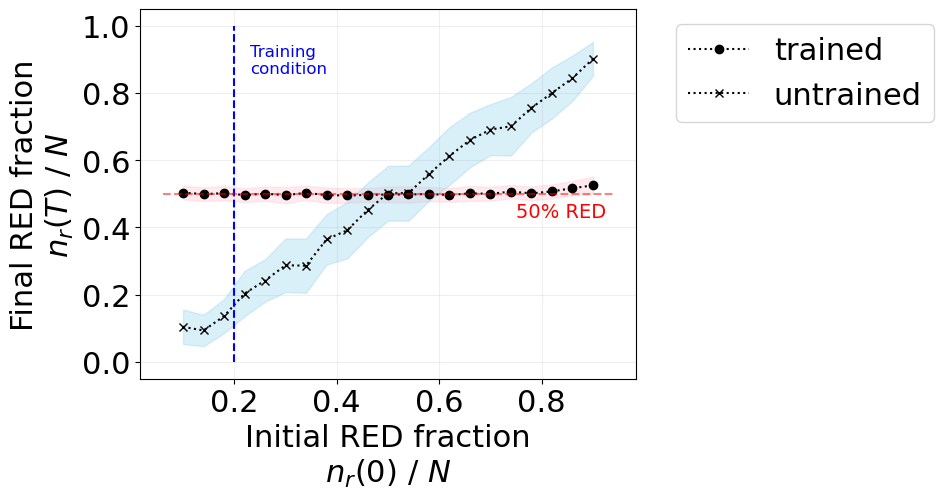

In [32]:
plt.plot(ctype_imbalances, imb_avgs_o, "ko:", label="trained")
plt.fill_between(
    ctype_imbalances,
    imb_avgs_o - imb_stds_o,
    imb_avgs_o + imb_stds_o,
    alpha=0.3,
    color="pink",
)

plt.plot(ctype_imbalances, imb_avgs_i, "kx:", label="untrained")
plt.fill_between(
    ctype_imbalances,
    imb_avgs_i - imb_stds_i,
    imb_avgs_i + imb_stds_i,
    alpha=0.3,
    color="skyblue",
)


plt.ylim(-0.05, 1.05)

plt.vlines(0.2, *(0.0, 1.0), linestyles="dashed", color="b")
plt.hlines(0.5, *plt.gca().get_xlim(), linestyles="dashed", color="r", alpha=0.5)

plt.text(
    0.23, 0.85, "Training\ncondition", ha="left", va="bottom", color="b", fontsize=12
)
plt.text(0.75, 0.42, "50% RED", ha="left", va="bottom", color="r", fontsize=14)

plt.xlabel("Initial RED fraction\n$ n_r (0)\\ /\\ N$")
plt.ylabel("Final RED fraction\n$ n_r (T)\\ /\\ N$")

plt.grid(alpha=0.2)

plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")


if SAVE_FIGURES:
    plt.savefig(
        f"figures/{EXPERIMENT}-{RUN_ID}-scaling-imbalances.svg", bbox_inches="tight"
    )

In [ ]:
if SAVE_FIGURES:
    import pandas as pd

    # Create lists of trained/untrained labels
    trained_labels = ["trained"] * len(imb_costs_trained)
    untrained_labels = ["untrained"] * len(imb_costs_untrained)

    # Create dataframes for trained and untrained data - transpose data to match ctype_imbalances columns
    df_trained = pd.DataFrame(np.array(imb_costs_trained).T, columns=ctype_imbalances)
    df_trained.insert(0, "model", ["trained"] * len(df_trained))

    df_untrained = pd.DataFrame(
        np.array(imb_costs_untrained).T, columns=ctype_imbalances
    )
    df_untrained.insert(0, "model", ["untrained"] * len(df_untrained))

    # Concatenate into single dataframe
    df = pd.concat([df_trained, df_untrained], ignore_index=True)

    # Save dataframe to CSV
    df.to_csv(f"figures/{EXPERIMENT}-{RUN_ID}-scaling-imbalance-data.csv", index=False)

# Alternative Networks

In [33]:
# Load all trained models from different runs

IDS = np.arange(opt_hyper["N_OPT_RUNS"]).tolist()

trained_models = []
loss_curves = []
for id in IDS:
    _, log, _, _, trained_model = load_run_data_fig3(id)
    trained_models += [trained_model]
    loss_curves += [log.val_loss]

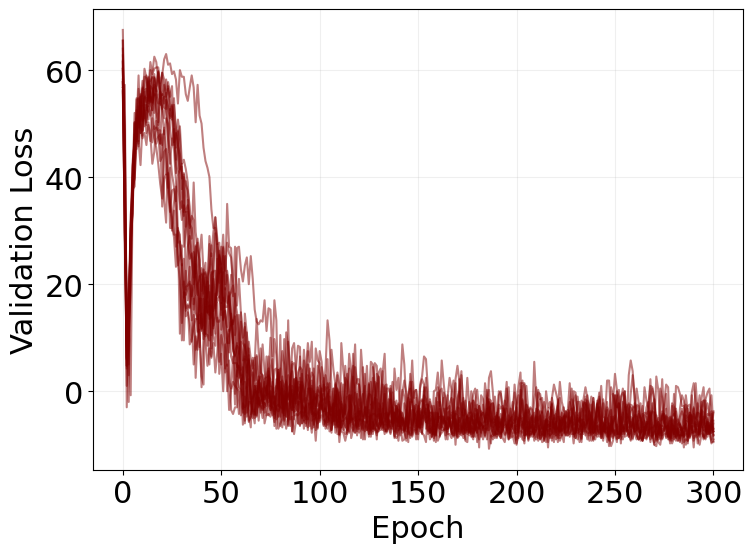

In [34]:
plt.figure(figsize=(8, 6))
plt.plot(np.array(loss_curves).T, color="maroon", alpha=0.5)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(alpha=0.2)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f"figures/loss_curves_{EXPERIMENT}-all.pdf", dpi=300)

In [35]:
# Make labels for network nodes

N_CHEM = istate.chemical.shape[-1]
N_HIDDEN = istate.hidden_state.shape[-1]

labels = []
labels += ["$c_{" + str(i + 1) + "}$" for i in range(N_CHEM)]
labels += ["$h_{" + str(i + 1) + "}$" for i in range(N_HIDDEN)]
labels += ["$s_{c_{" + str(i + 1) + "}}$" for i in range(N_CHEM)]
labels += ["div"]


inputs = [i for i in range(N_CHEM)]
hidden = [i for i in range(inputs[-1] + 1, inputs[-1] + 1 + N_HIDDEN)]
outputs = [i for i in range(hidden[-1] + 1, hidden[-1] + 1 + N_CHEM + 1)]
shells = [outputs, hidden, inputs]

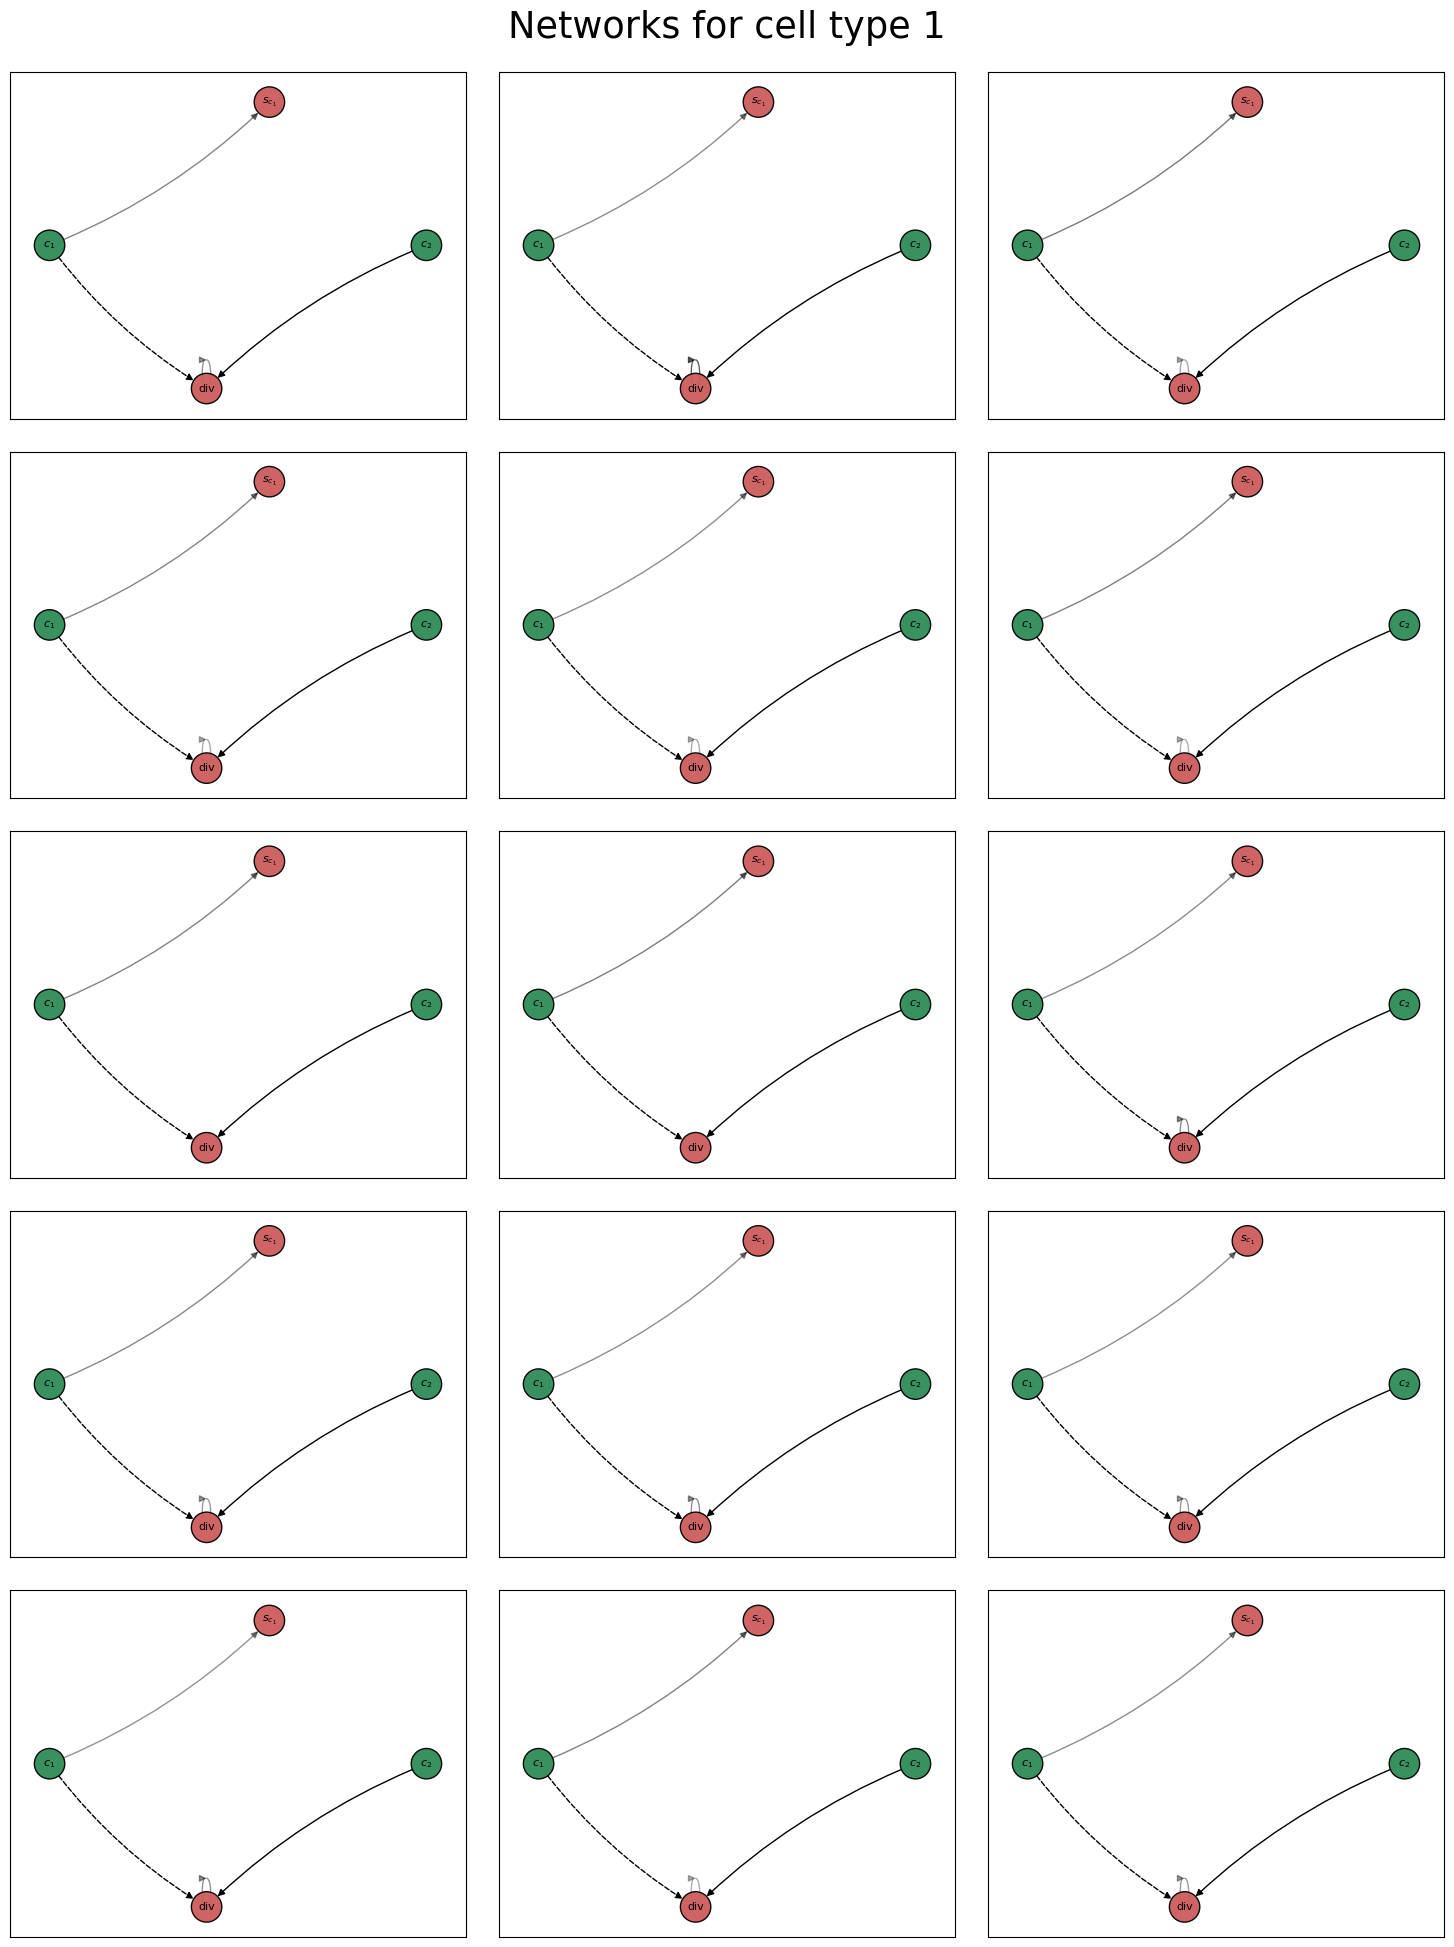

In [36]:
fig, axs = plt.subplots(5, 3, figsize=(15, 20))

for i, ax in enumerate(axs.flatten()):
    jxm.visualization.OLD_draw_network(
        trained_models[i][-2].interaction_matrix[0, :, :],
        eps=0.1,
        labels=labels,
        shells=shells,
        ax=ax,
    )

fig.suptitle("Networks for cell type 1")

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f"figures/{EXPERIMENT}-networks-ctype1.pdf", bbox_inches="tight")

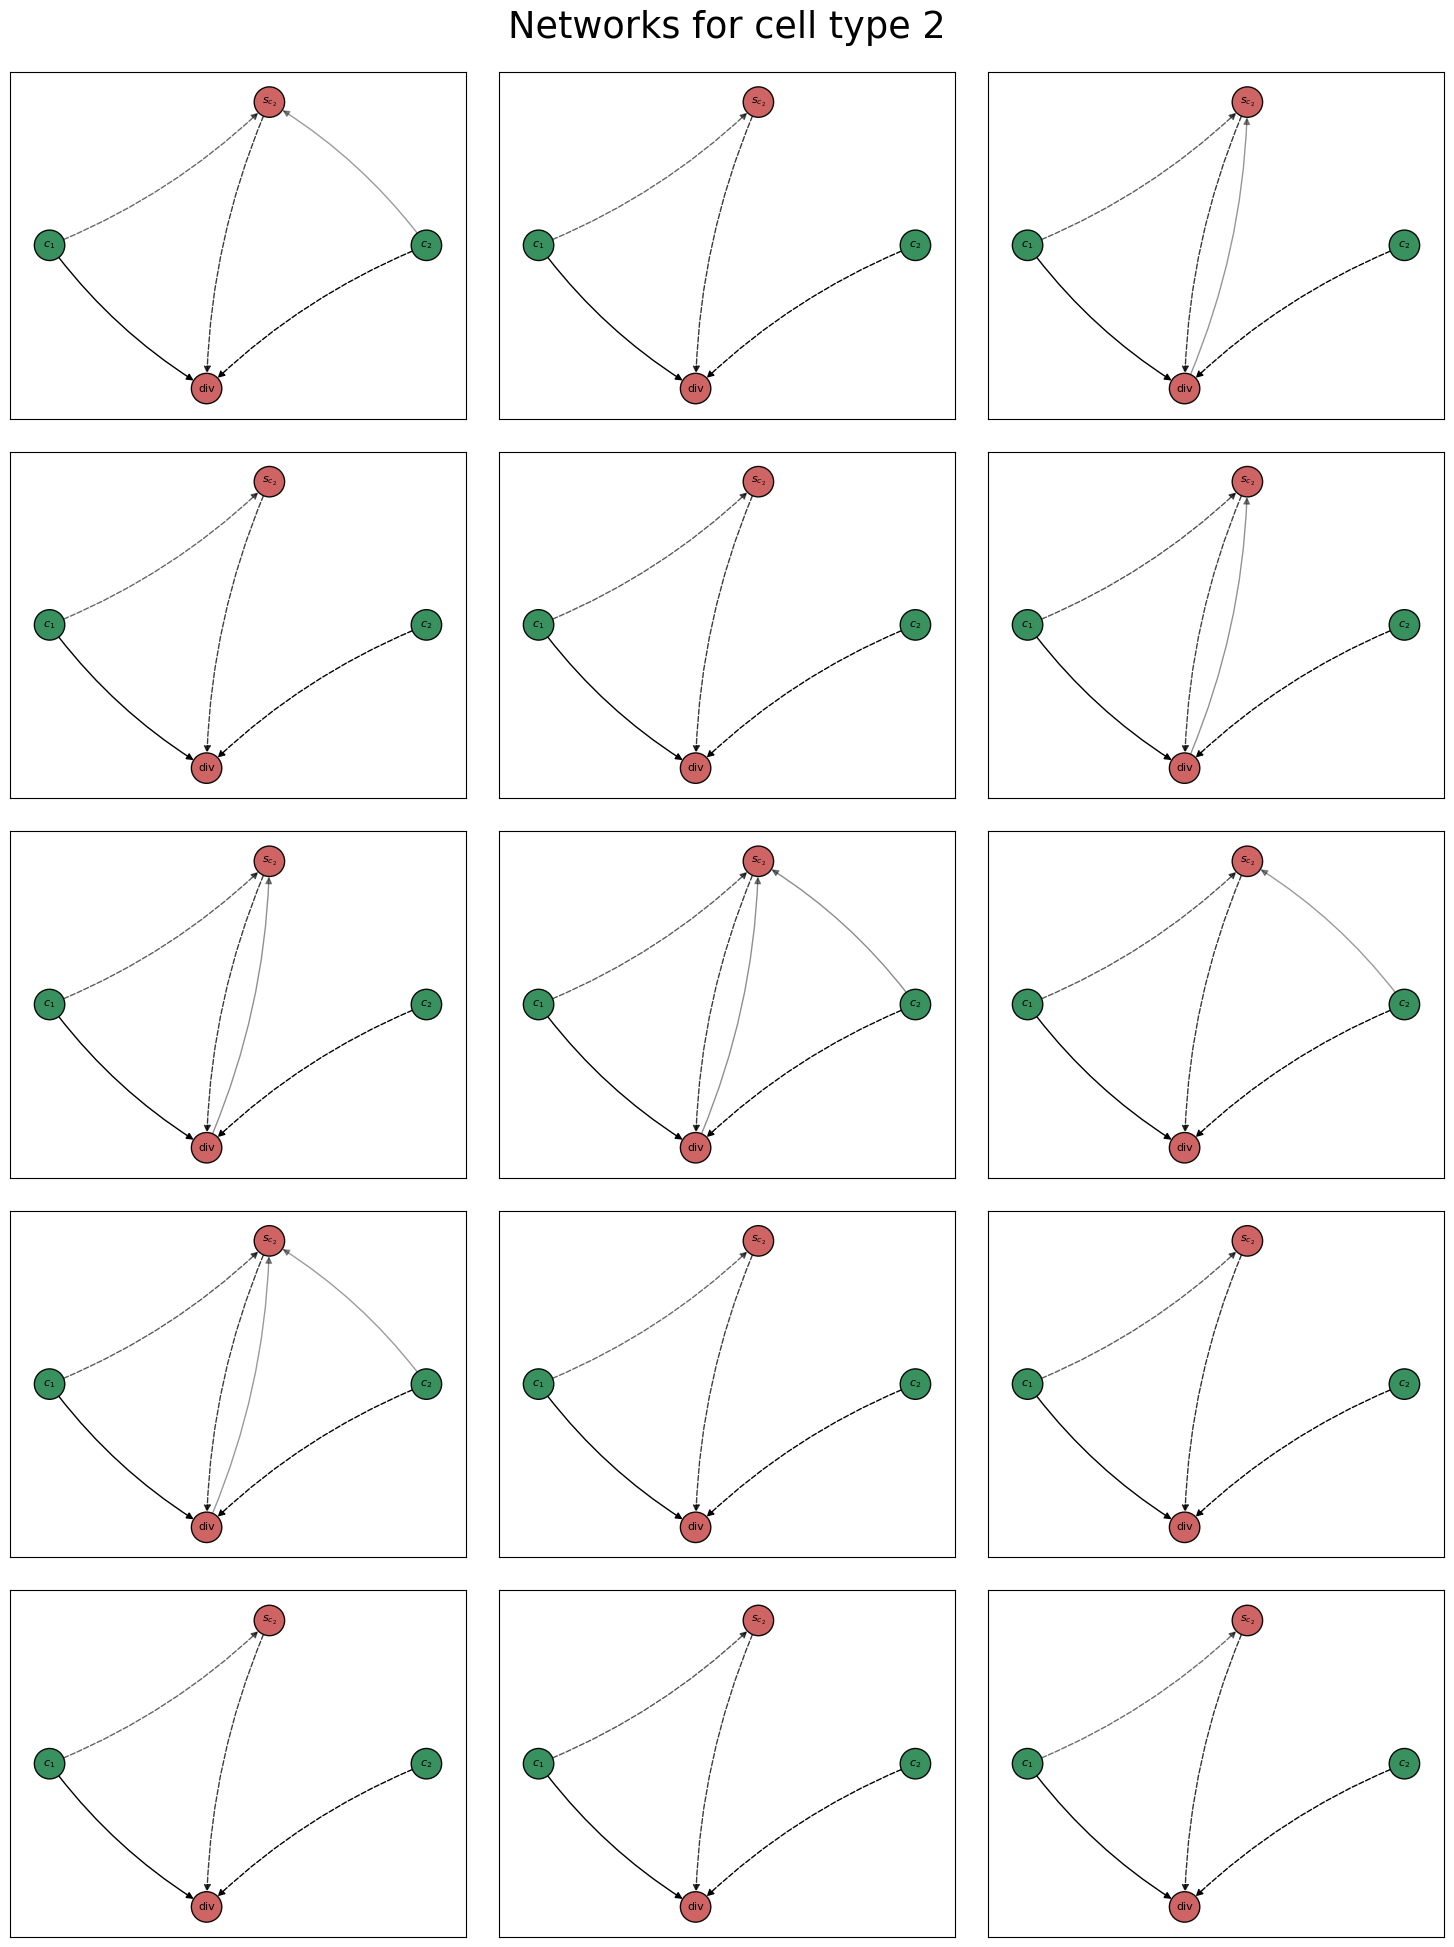

In [37]:
fig, axs = plt.subplots(5, 3, figsize=(15, 20))

for i, ax in enumerate(axs.flatten()):
    jxm.visualization.OLD_draw_network(
        trained_models[i][-2].interaction_matrix[1, :, :],
        eps=0.1,
        labels=labels,
        shells=shells,
        ax=ax,
    )

fig.suptitle("Networks for cell type 2")

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f"figures/{EXPERIMENT}-networks-ctype2.pdf", bbox_inches="tight")